# 03 — OOS 2025/2026 + портфель за всё время

Тот же scale-in (iter02), БЕЗ перетюна. Один проход по полной истории каждого
символа (2024-01 → 2026), кластеры детектятся один раз; затем:
1. **OOS per-trade** — статистика scale-in, разбитая по ГОДУ входа. Держится ли?
2. **Портфель** $1000 / $20 на сделку, ≤50 одновременных (реальные таймстампы) →
   общий PnL, годовая доходность, реализованный maxDD.

Параметры идентичны iter02: −5%/−7%/15m, COOLDOWN=10, MIN_GAP=3, N_MAX=10,
рамп «поздние крупнее», вход t+1, выход cluster_end+240, FEE 0.075%/side.

In [1]:
import sys; sys.path.insert(0,".")
from _lab import *
import numpy as np, pandas as pd
from pathlib import Path

# universe: same 50 symbols as iter00-02
z=np.load(Path("_out")/"closes_2024.npz",allow_pickle=True)
SYMS=list(z.files)
print("symbols:", len(SYMS))

WIN=15; H=240; COOLDOWN=10; MIN_GAP=3; N_MAX=10; FEE=0.00075

def clusters(c,thr):
    if len(c)<WIN+5: return []
    r=np.full(len(c),np.nan); r[WIN:]=c[WIN:]/c[:-WIN]-1
    cond=r<=-thr; out=[]; i=WIN; n=len(c)
    while i<n:
        if not cond[i] or (i>0 and cond[i-1]): i+=1; continue
        start=i; last_true=i; tr=[i]; lastt=i; falses=0; j=i+1
        while j<n:
            if cond[j]:
                last_true=j; falses=0
                if j-lastt>=MIN_GAP and len(tr)<N_MAX: tr.append(j); lastt=j
            else:
                falses+=1
                if falses>=COOLDOWN: break
            j+=1
        out.append((start,last_true,tr)); i=last_true+COOLDOWN+1
    return out

def trades(c,thr):
    # returns list of (entry_pos, exit_pos, pnl_single_net, pnl_scaled_net)
    res=[]; n=len(c)
    for (st,en,tr) in clusters(c,thr):
        ex=en+1+H
        if ex>=n or st+1>=n: continue
        exitp=c[ex]
        e_single=c[st+1]
        prices=np.array([c[t+1] for t in tr if t+1<n])
        ws=np.arange(1,len(prices)+1,dtype=float); ws/=ws.sum()
        avg=(ws*prices).sum()
        res.append((st+1, ex, exitp/e_single-1-2*FEE, exitp/avg-1-2*FEE))
    return res

symbols: 50


In [2]:
# ONE full-history load per symbol (close + timestamps); detect trades; tag by year
ALL={}  # thr -> list of dicts
for thr in (0.05,0.07): ALL[thr]=[]
for k,s in enumerate(SYMS):
    try:
        df=ohlcv(s,"2024-01-01","2026-07-01","1min")
    except Exception as e:
        print("skip",s,e); continue
    c=df["close"].to_numpy("float64"); ts=df.index
    for thr in (0.05,0.07):
        for (ep,xp,ps,psc) in trades(c,thr):
            ALL[thr].append(dict(sym=s, entry=ts[ep], exit=ts[xp],
                                 year=ts[ep].year, single=ps, scaled=psc))
    if (k+1)%10==0: print(f"  {k+1}/{len(SYMS)}")
for thr in (0.05,0.07): print(f"-{int(thr*100)}%: {len(ALL[thr])} trades total")

  10/50


  20/50


  30/50


  40/50


  50/50
-5%: 3069 trades total
-7%: 1302 trades total


In [3]:
# OOS per-trade stats by entry YEAR
def st(a):
    a=np.array(a)
    return (len(a),a.mean()*100,np.median(a)*100,(a>0).mean()*100,
            np.quantile(a,.10)*100, a.mean()/a.std() if a.std()>0 else np.nan)
for thr in (0.05,0.07):
    print(f"\n=== -{int(thr*100)}%/15m  SCALE-IN, net, by entry year ===")
    df=pd.DataFrame(ALL[thr])
    for y in sorted(df.year.unique()):
        a=df[df.year==y]['scaled']
        n,m,md_,w,q,ms=st(a)
        print(f"  {y}:  n={n:5d}  mean {m:+6.2f}  med {md_:+6.2f}  win {w:4.1f}%  q10 {q:+6.2f}  m/std {ms:+.3f}")
    n,m,md_,w,q,ms=st(df['scaled'])
    print(f"  ALL:  n={n:5d}  mean {m:+6.2f}  med {md_:+6.2f}  win {w:4.1f}%  q10 {q:+6.2f}  m/std {ms:+.3f}")


=== -5%/15m  SCALE-IN, net, by entry year ===
  2024:  n= 1727  mean  +1.82  med  +2.25  win 65.5%  q10  -5.16  m/std +0.313
  2025:  n=  987  mean  +1.14  med  +0.77  win 56.8%  q10  -6.65  m/std +0.137
  2026:  n=  355  mean  +0.92  med  +0.90  win 57.5%  q10  -6.83  m/std +0.110
  ALL:  n= 3069  mean  +1.50  med  +1.50  win 61.8%  q10  -5.74  m/std +0.212

=== -7%/15m  SCALE-IN, net, by entry year ===
  2024:  n=  776  mean  +3.42  med  +4.09  win 73.6%  q10  -4.28  m/std +0.561
  2025:  n=  378  mean  +4.29  med  +1.95  win 66.7%  q10  -8.54  m/std +0.326
  2026:  n=  148  mean  +3.05  med  +4.00  win 70.3%  q10  -5.93  m/std +0.302
  ALL:  n= 1302  mean  +3.63  med  +3.69  win 71.2%  q10  -5.23  m/std +0.395


In [4]:
# IDEALIZED per-trade sum (NOT a real return: ignores overlap + capital cap)
print("=== IDEALIZED sum of per-trade scaled net PnL (NOT realizable) ===")
for thr in (0.05,0.07):
    df=pd.DataFrame(ALL[thr])
    print(f"-{int(thr*100)}%:")
    for y in sorted(df.year.unique()):
        s=df[df.year==y]['scaled'].sum()*100
        print(f"    {y}: sum {s:+8.1f}%  (n={ (df.year==y).sum() })")
    print(f"    ALL: sum {df['scaled'].sum()*100:+8.1f}%")

=== IDEALIZED sum of per-trade scaled net PnL (NOT realizable) ===
-5%:
    2024: sum  +3147.8%  (n=1727)
    2025: sum  +1129.4%  (n=987)
    2026: sum   +325.7%  (n=355)
    ALL: sum  +4602.9%
-7%:
    2024: sum  +2652.3%  (n=776)
    2025: sum  +1620.3%  (n=378)
    2026: sum   +451.8%  (n=148)
    ALL: sum  +4724.4%


-5%: trades taken 2817 (skipped 252 = 8.2% capacity), span 2.32y
   final $1568  total return +56.8%  avg/yr +24.4%  realized maxDD -8.9%
-7%: trades taken 1221 (skipped 81 = 6.2% capacity), span 2.31y
   final $1805  total return +80.5%  avg/yr +34.9%  realized maxDD -4.6%


[saved] notebooks\dump\_out\03_portfolio.png


WindowsPath('C:/projects/researchlab/notebooks/dump/_out/03_portfolio.png')

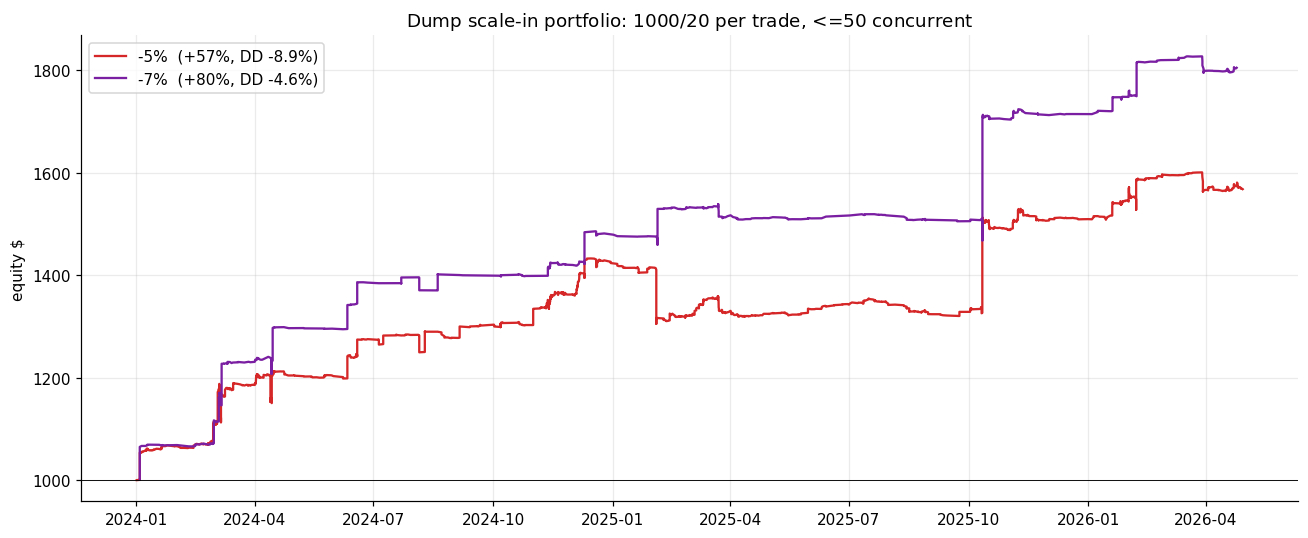

In [5]:
# REALISTIC portfolio: $1000 start, $20/trade fixed, <=50 concurrent (capacity).
# event-driven over real timestamps; PnL realized at exit (non-compounding size).
def portfolio(thr, START=1000.0, PER=20.0, MAX_CONC=50):
    df=pd.DataFrame(ALL[thr]).sort_values("entry").reset_index(drop=True)
    cash=START; open_trades=[]  # (exit_ts, pnl)
    eq_t=[]; eq_v=[]; peak=START; maxdd=0.0; taken=0; skipped=0
    import heapq
    for _,row in df.iterrows():
        now=row.entry
        # close matured trades
        while open_trades and open_trades[0][0]<=now:
            _,pnl=heapq.heappop(open_trades)
            cash+=PER*pnl
            eq_t.append(now); eq_v.append(cash)
            peak=max(peak,cash); maxdd=min(maxdd,cash/peak-1)
        if len(open_trades)<MAX_CONC:
            heapq.heappush(open_trades,(row.exit,row.scaled)); taken+=1
        else:
            skipped+=1
    # drain remaining
    for ex,pnl in sorted(open_trades):
        cash+=PER*pnl; eq_t.append(ex); eq_v.append(cash)
        peak=max(peak,cash); maxdd=min(maxdd,cash/peak-1)
    return df,np.array(eq_t),np.array(eq_v),cash,maxdd,taken,skipped

import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
for thr,col in [(0.05,"#d62728"),(0.07,"#7b1fa2")]:
    df,et,ev,final,maxdd,taken,skipped=portfolio(thr)
    span_days=(df.entry.max()-df.entry.min()).days
    yrs=span_days/365.25
    tot=final/1000-1
    print(f"-{int(thr*100)}%: trades taken {taken} (skipped {skipped} = {skipped/(taken+skipped)*100:.1f}% capacity), "
          f"span {yrs:.2f}y\n   final ${final:.0f}  total return {tot*100:+.1f}%  "
          f"avg/yr {tot/yrs*100:+.1f}%  realized maxDD {maxdd*100:.1f}%")
    plt.plot(et,ev,color=col,label=f"-{int(thr*100)}%  (+{tot*100:.0f}%, DD {maxdd*100:.1f}%)")
plt.axhline(1000,color="k",lw=.6); plt.ylabel("equity $"); plt.title("Dump scale-in portfolio: $1000 / $20 per trade, <=50 concurrent")
plt.legend(); show("03_portfolio")

## Как читать
- **OOS таблица по годам:** держится ли scale-in edge на 2025/2026 без перетюна.
  Смотри mean/std и mean — должны оставаться положительными и сопоставимыми.
- **Idealized sum** — НЕ реальная доходность (игнорит перекрытие сделок и лимит
  капитала). Дан только для масштаба, как в pump-07.
- **Портфель** — реалистично: $20/сделку, ≤50 параллельно, PnL без реинвеста.
  total return, avg/год, реализованный maxDD. skipped% = как часто упирались в
  ёмкость (срабатывает в кластерах = защитно).

*Verdict после прогона.*

## VERDICT (iter 03)

**OOS держится, особенно глубокие дампы.** Scale-in net per-trade по году входа:
- −7%/15m: 2024 +3.42% / 2025 +4.29% / 2026 +3.05% (m/std 0.561/0.326/0.302) —
  робастно на трёх независимых периодах, как pump.
- −5%/15m: +1.82/+1.14/+0.92% — положительно, но СЛАБЕЕТ (m/std 0.31→0.14→0.11,
  к 2026 кост-маргинал). Глубина важна → предпочтение −7%.

**PnL за всё время (2.3 года):**
- Идеализированная сумма по сделкам (НЕ реализуема, игнорит overlap+капитал):
  −5% +4603%, −7% +4724%. Только для масштаба.
- Реалистичный портфель $1000/$20/≤50 одновр.: −7% **+80.5% total, +34.9%/год,
  maxDD −4.6%**, skip 6.2%; −5% +56.8%, +24.4%/год, DD −8.9%, skip 8.2%.

**Кривая ступенчатая** — доход сконцентрирован в нескольких рыночных дамп-эпизодах
(резкий рывок окт-ноя 2025). Short-vol/коррелированная природа (зеркало pump),
лумпи-доход = риск single-window.

**⚠ Survivorship не учтён и тут критичен** (умершие после дампа монеты выпали →
доход завышен). Следующий шаг.